# Dataset / Imports:

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

## Libraries


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.decomposition import PCA
import warnings
import librosa
import librosa.display
import numpy as np
import glob
import os

print("Versions des librairies importantes :")
print(f"  Librosa:      {librosa.__version__}")
print(f"  NumPy:        {np.__version__}")

## Dataset

In [ ]:
dataset_path = "/content/drive/MyDrive/Artishow/Data/genres_original"

subfolders = os.listdir(dataset_path)
print("Sous-dossiers:", subfolders)

audio_files = glob.glob(f"{dataset_path}/**/*.wav", recursive=True)
print(f"Nombre de fichiers audio: {len(audio_files)}")

# PHASE 1 : Classificateurs de genres - Genre Classifiers


## Approche 1 : Machine Learning Classifiers

### Extraction des features


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import joblib
import os
import zipfile
from IPython.display import FileLink

X = [] #features
Y = [] #labels

def extract_features(file_path, duration=30, sr=22050):
    y, sr = librosa.load(file_path, sr=sr, duration=duration)

    # Fonction pour extraire la moyenne et l'écart-type
    def stats(feature):
        return list(map(float, np.mean(feature, axis=1))) + list(map(float, np.std(feature, axis=1)))

    # Extraction des features
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    print(len(mfcc[0]))
    rms = librosa.feature.rms(y=y)
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    flatness = librosa.feature.spectral_flatness(y=y)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    tonnetz = librosa.feature.tonnetz(y=y, sr=sr)
    zero_crossing = librosa.feature.zero_crossing_rate(y=y)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

    # Construction du vecteur de features
    features = []
    for f in [mfcc, rms, spectral_centroid, bandwidth, contrast, flatness, rolloff, tonnetz, zero_crossing]:
        features.extend(stats(f))
    features.append(float(tempo))

    genre = (os.path.splitext(os.path.basename(file_path))[0]).split('.')[0]
    print("Genre connu : " + genre)
    print("")

    X.append(features)
    Y.append(genre)

i = 0
for file in audio_files:
    i+=1
    print(i)
    extract_features(file)

df = pd.DataFrame(X)
df['genre'] = Y
df['genre'] = df['genre'].astype('category')
genre_mapping = dict(enumerate(df['genre'].cat.categories))
df['genre'] = df['genre'].astype('category').cat.codes

X_train, X_test, Y_train, Y_test = train_test_split(df.drop(columns=['genre'],), df['genre'], test_size=0.2, random_state = 42,stratify = Y)
print(Y_train.tolist())
print(Y_test.tolist())

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

save_dir = '/content/drive/MyDrive/Artishow/Modèle/ML'

# Sauvegarde des fichiers
joblib.dump(X_train, os.path.join(save_dir, "X_train.pkl"))
joblib.dump(X_test, os.path.join(save_dir, "X_test.pkl"))
joblib.dump(Y_train, os.path.join(save_dir, "Y_train.pkl"))
joblib.dump(Y_test, os.path.join(save_dir, "Y_test.pkl"))
joblib.dump(scaler, os.path.join(save_dir, "scaler.pkl"))
joblib.dump(genre_mapping, os.path.join(save_dir, "genre_mapping.pkl"))

files_to_zip = [
    "X_train.pkl",
    "X_test.pkl",
    "Y_train.pkl",
    "Y_test.pkl",
    "scaler.pkl",
    "genre_mapping.pkl"
]

zip_filename = "features_data.zip"
zip_path = os.path.join(save_dir, zip_filename)

with zipfile.ZipFile(zip_path, "w") as zipf:
    for filename in files_to_zip:
        file_path = os.path.join(save_dir, filename)
        zipf.write(file_path, arcname=filename)

# Lien pour télécharger
display(FileLink(zip_path))

In [ ]:
# Stocker les features/labels

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import joblib
import os
import zipfile
from IPython.display import FileLink

X = [] #features
Y = [] #labels

def extract_features(file_path, duration=30, sr=22050):
    y, sr = librosa.load(file_path, sr=sr, duration=duration)

    # Fonction pour extraire la moyenne et l'écart-type
    def stats(feature):
        return list(map(float, np.mean(feature, axis=1))) + list(map(float, np.std(feature, axis=1)))

    # Extraction des features
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    print(len(mfcc[0]))
    rms = librosa.feature.rms(y=y)
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    flatness = librosa.feature.spectral_flatness(y=y)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    tonnetz = librosa.feature.tonnetz(y=y, sr=sr)
    zero_crossing = librosa.feature.zero_crossing_rate(y=y)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

    # Construction du vecteur de features
    features = []
    for f in [mfcc, rms, spectral_centroid, bandwidth, contrast, flatness, rolloff, tonnetz, zero_crossing]:
        features.extend(stats(f))
    features.append(float(tempo))

    genre = (os.path.splitext(os.path.basename(file_path))[0]).split('.')[0]
    print("Genre connu : " + genre)

    """print(np.array(features, dtype=np.float32))"""  # Conversion finale
    print("")

    X.append(features)
    Y.append(genre)

### Fichiers Préentrainés

In [ ]:
# Fichiers Préentrainés (GTZAN)
import joblib
import os

X_train = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML/X_train.pkl')
Y_train = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML/Y_train.pkl')
X_test = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML/X_test.pkl')
Y_test = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML/Y_test.pkl')
genre_mapping = {0: 'blues', 1: 'classical', 2: 'country', 3: 'disco', 4: 'hiphop', 5: 'jazz', 6: 'metal', 7: 'pop', 8: 'reggae', 9: 'rock'}

print(Y_train)
print(genre_mapping)

In [ ]:
# Fichiers Préentrainés (MTG-JAMENDO)
import joblib
import os

X_train_mood = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML_moods/X_train.pkl')
Y_train_mood = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML_moods/Y_train.pkl')
X_test_mood = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML_moods/X_test.pkl')
Y_test_mood = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML_moods/Y_test.pkl')
mood_mapping = {0: 'dark', 1: 'deep', 2: 'dream', 3: 'emotional', 4: 'epic', 5: 'happy', 6: 'motivational', 7: 'relaxing', 8: 'romantic', 9: 'sad'}

print(Y_train_mood)
print(mood_mapping)

### Classifiers

In [ ]:
#SVM

from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score


#Genre
model = SVC(kernel='linear')
model.fit(X_train, Y_train)
save_dir = '/content/drive/MyDrive/Artishow/Modèle/ML'
joblib.dump(model, os.path.join(save_dir, "svm_model.pkl"))

pred = model.predict(X_test)
print("Prédiction (Genre) : " + str(pred))

accuracy = accuracy_score(Y_test, pred)
print(f'Précision (Genre) : {accuracy:.2%}')


#Mood
model_mood = SVC(kernel='linear')
model_mood.fit(X_train_mood, Y_train_mood)
save_dir = '/content/drive/MyDrive/Artishow/Modèle/ML_moods'
joblib.dump(model_mood, os.path.join(save_dir, "svm_model_mood.pkl"))

pred_mood = model_mood.predict(X_test_mood)
print("Prédiction (Mood) : " + str(pred_mood))

accuracy = accuracy_score(Y_test_mood, pred_mood)
print(f'Précision (Mood) : {accuracy:.2%}')




In [ ]:
#LogisticRegression

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

#Mood
model = LogisticRegression()
model.fit(X_train, Y_train)

pred = model.predict(X_test)
save_dir = '/content/drive/MyDrive/Artishow/Modèle/ML'
joblib.dump(model, os.path.join(save_dir, "LogisticRegModel.pkl"))

print("Prédiction (Genre) : " + str(pred))
accuracy = accuracy_score(Y_test, pred)
print(f'Précision (Genre) : {accuracy:.2%}')


#Genre
model_mood = LogisticRegression()
model_mood.fit(X_train_mood, Y_train_mood)

pred_mood = model_mood.predict(X_test_mood)
save_dir = '/content/drive/MyDrive/Artishow/Modèle/ML_moods'
joblib.dump(model_mood, os.path.join(save_dir, "LogisticRegModel_mood.pkl"))

print("Prédiction (Genre) : " + str(pred_mood))
accuracy = accuracy_score(Y_test_mood, pred_mood)
print(f'Précision (Genre) : {accuracy:.2%}')

In [ ]:
#RandomForest

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier


#Genre
rf_model = RandomForestClassifier(n_estimators=103, random_state=42)

rf_model.fit(X_train, Y_train)
Y_pred = rf_model.predict(X_test)
save_dir = '/content/drive/MyDrive/Artishow/Modèle/ML'
joblib.dump(rf_model, os.path.join(save_dir, "rf_model.pkl"))

accuracy = accuracy_score(Y_test, Y_pred)
print("Prédiction (Genre)", Y_pred)
print(f"Précision (Genre) : {accuracy:.2%}")

#Mood
rf_model_mood = RandomForestClassifier(n_estimators=103, random_state=42)

rf_model_mood.fit(X_train_mood, Y_train_mood)
Y_pred_mood = rf_model_mood.predict(X_test_mood)
save_dir = '/content/drive/MyDrive/Artishow/Modèle/ML_moods'
joblib.dump(rf_model, os.path.join(save_dir, "rf_model_mood.pkl"))

accuracy = accuracy_score(Y_test_mood, Y_pred_mood)
print("Prédiction (Mood)", Y_pred_mood)
print(f"Précision (Mood) : {accuracy:.2%}")


In [ ]:
#GradientBoosting

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

#Genre
model_gbt = GradientBoostingClassifier()
model_gbt.fit(X_train, Y_train)
save_dir = '/content/drive/MyDrive/Artishow/Modèle/ML'
joblib.dump(model_gbt, os.path.join(save_dir, "gbt_model.pkl"))
Y_pred_gbt = model_gbt.predict(X_test)
accuracy = accuracy_score(Y_test, Y_pred_gbt)
print("Prédiction (Genre)", Y_pred)
print(f"Précision (Genre)): {accuracy:.2%}")

#Mood
model_gbt_mood = GradientBoostingClassifier()
model_gbt_mood.fit(X_train_mood, Y_train_mood)
save_dir = '/content/drive/MyDrive/Artishow/Modèle/ML_moods'
joblib.dump(model_gbt_mood, os.path.join(save_dir, "gbt_model_mood.pkl"))
Y_pred_gbt_mood = model_gbt_mood.predict(X_test_mood)
accuracy = accuracy_score(Y_test_mood, Y_pred_gbt_mood)
print("Prédiction (Mood)", Y_pred_gbt_mood)
print(f"Précision (Mood): {accuracy:.2%}")

In [ ]:
#K-Nearest Neighbors

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

#Genre
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, Y_train)

pred_k = knn.predict(X_test)
save_dir = '/content/drive/MyDrive/Artishow/Modèle/ML'
joblib.dump(knn, os.path.join(save_dir, "knn_model.pkl"))

print("Prédiction (Genre) :" + str(pred_k))
accuracy = accuracy_score(Y_test, pred_k)
print(f'Précision (Genre): {accuracy:.2%}')


#Mood
knn_mood = KNeighborsClassifier(n_neighbors=5)
knn_mood.fit(X_train_mood, Y_train_mood)

pred_k_mood = knn_mood.predict(X_test_mood)
save_dir = '/content/drive/MyDrive/Artishow/Modèle/ML_moods'
joblib.dump(knn, os.path.join(save_dir, "knn_model_mood.pkl"))

print("Prédiction (Mood) :" + str(pred_k_mood))
accuracy = accuracy_score(Y_test_mood, pred_k_mood)
print(f'Précision (Mood): {accuracy:.2%}')

In [ ]:
#Version 2 pas fini : Pour tester sur une musique de son choix - To try on a chosen music

import joblib

X_genre = []
X_mood = []

def pred_musique2(file_path, model_genre):

  extract_features(file_path, duration=30, sr=22050)
  df_test = pd.DataFrame(X)
  scaler = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML/scaler.pkl')
  df_test_scaled = scaler.transform(df_test)
  prediction = model.predict(df_test_scaled)
  print(f"Prédiction (Genre): {genre_mapping[int(prediction[0])]}")
  X.clear()




def pred_musique(file_path, model):
  extract_features(file_path, duration=30, sr=22050)
  df_test = pd.DataFrame(X)
  scaler = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML/scaler.pkl')
  df_test_scaled = scaler.transform(df_test)
  prediction = model.predict(df_test_scaled)
  print(f"Prédiction (Genre): {genre_mapping[int(prediction[0])]}")
  X.clear()
  return genre_mapping[int(prediction[0])]


svm_model = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML/svm_model.pkl')
knn_model = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML/knn_model.pkl')
gbt_model = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML/gbt_model.pkl')
rf_model = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML/rf_model.pkl')
LogisticRegModel = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML/LogisticRegModel.pkl')

svm_model_mood = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML_moods/svm_model_mood.pkl')
knn_model_mood = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML_moods/knn_model_mood.pkl')
gbt_model_mood = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML_moods/gbt_model_mood.pkl')
rf_model_mood = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML_moods/rf_model_mood.pkl')
LogisticRegModel_mood = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML_moods/LogisticRegModel_mood.pkl')

def pred_globale(file_path):
  print("==== SVM ====")
  pred_musique2(file_path, svm_model)
  print("==== KNN ====")
  pred_musique2(file_path, knn_model)
  print("==== Gradient Boosting ====")
  pred_musique2(file_path, gbt_model)
  print("==== Random Forest ====")
  pred_musique2(file_path, rf_model)
  print("==== Logistic Regression ====")
  pred_musique2(file_path, LogisticRegModel)

pred_globale('/content/drive/MyDrive/Artishow/Musique perso/Dua Lipa - Houdini.mp3')

In [ ]:
#V1 pour tester sur une musique de son choix (GENRE)

X_genre = []
X_mood = []

def pred_musique_2(file_path, model_genre, model_mood):

  extract_features(file_path, duration=30, sr=22050)

  #Genre
  df_test = pd.DataFrame(X_genre)
  scaler = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML/scaler.pkl')
  df_test_scaled = scaler.transform(df_test)
  prediction = model_genre.predict(df_test_scaled)
  print(f"Prédiction (Genre): {genre_mapping[int(prediction[0])]}")
  X_genre.clear()

  #Mood
  df_test_mood = pd.DataFrame(X_mood)
  scaler_mood = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML_moods/scaler.pkl')
  df_test_scaled_mood = scaler_mood.transform(df_test_mood)
  prediction = model_mood.predict(df_test_scaled_mood)
  print(prediction)
  print(f"Prédiction (Mood): {mood_mapping[int(prediction[0])]}")
  X_mood.clear()


def pred_musique(file_path, model):
  extract_features(file_path, duration=30, sr=22050)
  df_test = pd.DataFrame(X)
  scaler = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML/scaler.pkl')
  df_test_scaled = scaler.transform(df_test)
  prediction = model.predict(df_test_scaled)
  print(f"Prédiction (Genre): {genre_mapping[int(prediction[0])]}")
  X.clear()
  return genre_mapping[int(prediction[0])]

def pred_musique_mood(file_path, model):
  extract_features(file_path, duration=30, sr=22050)
  df_test = pd.DataFrame(X)
  scaler = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML_moods/scaler.pkl')
  df_test_scaled = scaler.transform(df_test)
  prediction = model.predict(df_test_scaled)
  print(prediction)
  print(f"Prédiction (Mood) : {mood_mapping[int(prediction[0])]}")
  X.clear()
  return mood_mapping[int(prediction[0])]

svm_model = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML/svm_model.pkl')
knn_model = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML/knn_model.pkl')
gbt_model = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML/gbt_model.pkl')
rf_model = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML/rf_model.pkl')
LogisticRegModel = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML/LogisticRegModel.pkl')

svm_model_mood = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML_moods/svm_model_mood.pkl')
knn_model_mood = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML_moods/knn_model_mood.pkl')
gbt_model_mood = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML_moods/gbt_model_mood.pkl')
rf_model_mood = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML_moods/rf_model_mood.pkl')
LogisticRegModel_mood = joblib.load('/content/drive/MyDrive/Artishow/Modèle/ML_moods/LogisticRegModel_mood.pkl')

def pred_globale(file_path):
  print("==== SVM ====")
  pred_musique(file_path, svm_model)
  pred_musique_mood(file_path, svm_model_mood)
  print("==== KNN ====")
  pred_musique(file_path, knn_model)
  pred_musique_mood(file_path, knn_model_mood)
  print("==== Gradient Boosting ====")
  pred_musique(file_path, gbt_model)
  pred_musique_mood(file_path, gbt_model_mood)
  print("==== Random Forest ====")
  pred_musique(file_path, rf_model)
  pred_musique_mood(file_path, rf_model_mood)
  print("==== Logistic Regression ====")
  pred_musique(file_path, LogisticRegModel)
  pred_musique_mood(file_path, LogisticRegModel_mood)

pred_globale('/content/drive/MyDrive/Artishow/Musique perso/Dua Lipa - Houdini.mp3')

## Approche 2 : CNN + Spectrograms


### Conversion en spectrogramme

In [ ]:
#Spectrogramme

import shutil
import os
import random


def audio_to_mel_spec(audio, save_path, sr=22050, n_mels=128, hop_length=512):
    y, sr = librosa.load(audio, sr=sr, duration=30)
    melspec = librosa.feature.melspectrogram(y=y, sr=sr,n_mels=n_mels
                                             , hop_length=hop_length)
    melspec_db = librosa.power_to_db(melspec, ref=np.max)

    # Plot & save spectrogram
    plt.figure(figsize=(4.32, 2.88), dpi=100)  # image 224x224 pixels
    #librosa.display.specshow(melspec_db)  # ou 'inferno'
    plt.imshow(melspec_db, aspect='auto', origin='lower', cmap='magma', vmin=-42, vmax=0)

    plt.axis('off')
    plt.tight_layout(pad=0)
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
    plt.show()

output_dir = "/content/drive/MyDrive/Artishow/spectrogramStorage"
i=0

for audio in audio_files[:1000]:
    i+=1
    print(i)
    file_name = os.path.basename(audio).replace('.mp3','.png').replace('.wav','.png')
    save_path = os.path.join(output_dir, file_name)
    print(file_name)
    audio_to_mel_spec(audio, save_path)

shutil.make_archive("/kaggle/working/dataset_spectrograms", 'zip', output_dir)
print("fichier créé pret a download")

In [ ]:
#Mettre en forme les données

import tensorflow as tf
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

spectrograms_dir = '/content/drive/MyDrive/Artishow/Data/images_original'
data = []

for genre in os.listdir(spectrograms_dir):
    genre_dir = os.path.join(spectrograms_dir, genre)
    if not os.path.isdir(genre_dir):
        continue
    for file in os.listdir(genre_dir):
        if file.endswith(".png"):
            file_path = os.path.join(genre_dir, file)
            data.append([file_path, genre])

df = pd.DataFrame(data, columns=["filename", "genre"])
display(df.head())

IMG_SIZE = (224,224)
BATCH_SIZE = 32
DATASET_DIR = "dataset_spectrograms"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_dataframe(
    dataframe = df,
    x_col="filename",
    y_col="genre",
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = "categorical",
    subset = "training"
)

val_generator = datagen.flow_from_dataframe(
    dataframe = df,
    x_col="filename",
    y_col="genre",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode = "categorical",
    subset = "validation"
)


### Convolutional Neural Network

In [ ]:
#VGG-16

import os
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

filepath = "/content/drive/MyDrive/Artishow/Modèle/IA/vgg16_weights_tf_dim_ordering_tf_kernels_notop (1).h5"
base_model = VGG16(weights=filepath,
                include_top=False,
                input_shape=((224,224, 3))
)

base_model.trainable = False
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(df['genre'].nunique(),activation='softmax')])

model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

model.save("/content/drive/MyDrive/Artishow/Modèle/IA/vgg16_genre_classification.h5")

loss, accuracy = model.evaluate(val_generator)

In [ ]:
from sklearn.metrics import accuracy_score

model = tf.keras.models.load_model("/content/drive/MyDrive/Artishow/Modèle/IA/vgg16_genre_classification.h5")
pred = model.predict(val_generator)

true_classes = val_generator.classes
pred_classes = np.argmax(pred, axis=1)
acc = accuracy_score(true_classes, pred_classes)
print(f"Accuracy sur validation set : {acc:.2%}")

In [ ]:
audio_to_mel_spec("/content/drive/MyDrive/Artishow/Musique perso/Dua Lipa - Houdini.mp3", "/content/drive/MyDrive/Artishow/spectrogramStorage/MusiquePerso/specPerso")
import keras.preprocessing.image as image
# Charger l’image et la préparer pour le modèle

def load_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.  # Si tu as utilisé rescale=1./255
    return img_array

# Charger ton modèle entraîné
model = tf.keras.models.load_model("/content/drive/MyDrive/Artishow/Modèle/IA/vgg16_genre_classification.h5")

# Exemple d'audio à prédire
spec_path = "/content/drive/MyDrive/Artishow/spectrogramStorage/MusiquePerso/specPerso.png"
img_array = load_image(spec_path)

# Prédiction
prediction = model.predict(img_array)
print(prediction)
predicted_indices = np.argsort(prediction)[0][-2:][::-1]
print(f"Genres prédits : {predicted_indices}")

## Benchmark

In [ ]:
#Benchmark

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(kernel='linear', probability=True),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=103, random_state=42)
}

results = []

def compute_f1_score(y_true, y_pred):
    return f1_score(y_true, y_pred, average='weighted')

def compute_auc(y_true, y_prob):
    if y_prob is not None:
        try:
            y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
            return roc_auc_score(y_true_bin, y_prob, average='weighted', multi_class='ovr')
        except ValueError:
            return None
    return None

print("Réponse :", Y_test.tolist())

#Entrainement

for name, model in models.items():
    model.fit(X_train, Y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    accuracy = accuracy_score(Y_test, pred)
    f1 = compute_f1_score(Y_test, pred)
    auc = compute_auc(Y_test, prob)
    print(f"Prédiction {name} : {pred}")
    results.append((name, accuracy, f1, auc))

#Affichage
results_df = pd.DataFrame(results, columns=["Modele", "Precision", "F1-Score", "AUC"])
print(results_df.sort_values(by="F1-Score", ascending=False))


In [ ]:
#Matrice de confusion
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


use_mood = False  # Mets False pour genre

mood_mapping = {0: 'dark', 1: 'deep', 2: 'dream', 3: 'emotional', 4: 'epic', 5: 'happy', 6: 'motivational', 7: 'relaxing', 8: 'romantic', 9: 'sad'}
genre_mapping = {0: 'blues', 1: 'classical', 2: 'country', 3: 'disco', 4: 'hiphop', 5: 'jazz', 6: 'metal', 7: 'pop', 8: 'reggae', 9: 'rock'}

mapping = mood_mapping if use_mood else genre_mapping
labels = [mapping[cle] for cle in mapping]

models = {
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(kernel='linear', probability=True),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=103, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, Y_train)
    pred = model.predict(X_test)
    cm = confusion_matrix(Y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", # fmt="d" pour afficher des entiers
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Prédictions')
    plt.ylabel('Vraies valeurs')
    plt.title(name)
    plt.show()


# PHASE 2 : Playlist


## Imports Deezer

In [ ]:
import os
import pandas as pd
import requests
import time
from google.colab import drive

TARGET = 1000
PLAYLIST_LIMIT = 50
API_SLEEP = 0.15

drive.mount('/content/drive')

base_path = '/content/drive/My Drive/Artishow_Wass/Deezer'
os.makedirs(base_path, exist_ok=True)

GENRES = ["hip hop",
    "pop",
    "rock",
    "electronic",
    "latin",
    "rnb",
    "dance",
    "reggaeton",
    "country",
    "jazz",
    "blues",
    "metal",
    "classical",
    "alternative",
    "indie",
    "funk",
    "folk",
    "punk",
    "disco",
    "gospel",
    "world music",
    "afrobeat",
    "k-pop",
    "trap",
    "house",
    "techno",
    "drum and bass",
    "ambient",
    "soundtrack",
    "latin pop"
]

def get_playlists_for_genre(genre, limit=PLAYLIST_LIMIT):
    url = f"https://api.deezer.com/search/playlist?q={genre}&limit={limit}"
    r = requests.get(url)
    if r.status_code != 200:
        return []
    return r.json().get("data", [])

def get_tracks_from_playlist(playlist_id):
    url = f"https://api.deezer.com/playlist/{playlist_id}"
    r = requests.get(url)
    if r.status_code != 200:
        return []

    tracks = r.json().get("tracks", {}).get("data", [])
    results = []

    for track in tracks:
        if not track.get("preview"):
            continue

        results.append({
            "track_id": track["id"],
            "title": track["title"],
            "artist": track["artist"]["name"],
            "rank": track.get("rank", 0),
            "preview": track["preview"]
        })

    return results

for genre in GENRES:
    print(f"\n🎧 Traitement du genre : {genre}")
    all_tracks = []

    safe_genre = genre.replace(" ", "_").replace("-", "_")
    genre_folder = os.path.join(base_path, safe_genre)
    os.makedirs(genre_folder, exist_ok=True)

    playlists = get_playlists_for_genre(genre)
    if not playlists:
        print(f"❌ Aucune playlist trouvée pour {genre}")
        continue

    for playlist in playlists:
        if len(all_tracks) >= TARGET:
            break

        playlist_id = playlist["id"]

        try:
            tracks = get_tracks_from_playlist(playlist_id)
            all_tracks.extend(tracks)
        except Exception as e:
            print(f"⚠️ Erreur playlist {playlist_id}: {e}")

        time.sleep(API_SLEEP)

    if not all_tracks:
        print(f"❌ Aucun morceau récupéré pour {genre}")
        continue

    df = pd.DataFrame(all_tracks)
    df.drop_duplicates(subset="track_id", inplace=True)
    df.sort_values(by="rank", ascending=False, inplace=True)

    if len(df) > TARGET:
        df = df.head(TARGET)

    print(f"✅ {len(df)} morceaux retenus pour {genre}")

    csv_path = os.path.join(genre_folder, f"{safe_genre}_top{len(df)}.csv")
    df.to_csv(csv_path, index=False)

    print(f"⬇️ Téléchargement des previews pour {genre}")

    for _, row in df.iterrows():
        track_id = row["track_id"]
        title = row["title"]
        preview_url = row["preview"]

        safe_title = title[:40].replace("/", "_").replace("\\", "_")
        filename = f"{track_id}_{safe_title}.mp3"
        filepath = os.path.join(genre_folder, filename)

        if os.path.exists(filepath):
            continue

        try:
            r = requests.get(preview_url)
            with open(filepath, "wb") as f:
                f.write(r.content)
        except:
            print(f"❌ Échec téléchargement : {title}")

    print(f"🎉 Genre terminé : {genre}")

print("\n🏁 TOUT EST TERMINÉ")


#CRNN

In [ ]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import shutil
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from google.colab import drive
import json

# 1. SETUP
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

BASE_PATH_DRIVE = '/content/drive/My Drive/Artishow_Wass/Deezer'
TEMP_SPECTRO_DIR = '/content/temp_spectrograms_hd'

# 2. LISTE SPÉCIFIQUE À REPRENDRE
# On ne traite QUE ces genres-là
GENRES_TO_PROCESS = [
    "funk", "folk", "punk", "disco", "gospel",
    "afrobeat", "k-pop", "trap", "house", "techno", "drum and bass"
]

# ⚠️ IMPORTANT : On ne supprime PLUS le dossier existant pour garder le travail précédent
os.makedirs(TEMP_SPECTRO_DIR, exist_ok=True)

IMG_SIZE = (224, 224)

print(f"\n🌊 Reprise de la génération HD (224x224) pour : {GENRES_TO_PROCESS}")

def generate_spectrogram(audio_path, save_path):
    try:
        y, sr = librosa.load(audio_path, sr=22050, duration=30)
        if len(y) < 22050 * 5: return False

        melspec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        melspec_db = librosa.power_to_db(melspec, ref=np.max)

        # --- TAILLE EXACTE 224x224 ---
        width_px, height_px = 224, 224
        dpi = 100

        fig = plt.figure(figsize=(width_px/dpi, height_px/dpi), dpi=dpi)
        ax = plt.Axes(fig, [0., 0., 1., 1.])
        ax.set_axis_off()
        fig.add_axes(ax)

        ax.imshow(melspec_db, aspect='auto', origin='lower', cmap='magma')

        plt.savefig(save_path, dpi=dpi)
        plt.close()

        return True
    except Exception as e:
        print(f"Erreur: {e}")
        return False

total_count = 0

for genre in GENRES_TO_PROCESS:
    # Gestion des noms de dossiers (espaces vs underscores)
    src_folder = os.path.join(BASE_PATH_DRIVE, genre)

    # Si le dossier n'est pas trouvé tel quel, on essaie avec des underscores
    if not os.path.exists(src_folder):
        alt_genre = genre.replace(" ", "_")
        src_folder = os.path.join(BASE_PATH_DRIVE, alt_genre)

    dst_folder = os.path.join(TEMP_SPECTRO_DIR, genre) # On garde le nom propre pour le dossier de destination
    os.makedirs(dst_folder, exist_ok=True)

    if not os.path.exists(src_folder):
        print(f"⚠️ Dossier introuvable pour le genre : {genre} (Passé)")
        continue

    files = [f for f in os.listdir(src_folder) if f.endswith('.mp3')]
    print(f"  -> Traitement {genre} ({len(files)} fichiers)...")

    for f in files:
        src = os.path.join(src_folder, f)
        dst = os.path.join(dst_folder, f.replace('.mp3', '.png'))

        # OPTIMISATION : Si l'image existe déjà, on la saute
        if os.path.exists(dst):
            continue

        if generate_spectrogram(src, dst):
            total_count += 1

print(f"✅ {total_count} NOUVELLES images HD générées.")

In [ ]:
import shutil
from google.colab import files

GENRES = ["hip hop",
    "pop",
    "rock",
    "latin",
    "rnb",
    "reggaeton",
    "country", "jazz", "blues", "metal", "classical", "funk", "folk", "punk", "disco", "gospel",
    "afrobeat", "k-pop", "trap", "house", "techno", "drum and bass"
]

shutil.make_archive(
    "/content/temp_spectrograms_hd",  # nom du zip (sans .zip)
    'zip',                         # format
    "/content",                    # dossier parent
    "temp_spectrograms_hd"            # dossier à zipper
)

files.download("/content/temp_spectrograms_hd.zip")


In [ ]:
import os
import shutil
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from google.colab import drive
import json

# 1. SETUP
# ======
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Chemins
SOURCE_DRIVE = '/content/drive/My Drive/Artishow_Wass/temp_spectrograms'
DEST_LOCAL = '/content/temp_spectrograms' # Disque rapide de Colab

GENRES = ["hip hop",
    "pop",
    "rock",
    "latin",
    "rnb",
    "reggaeton",
    "country", "jazz", "blues", "metal", "classical", "funk", "folk", "punk", "disco", "gospel",
    "afrobeat", "k-pop", "trap", "house", "techno", "drum and bass"
]

# 2. IMPORTATION RAPIDE (DRIVE -> LOCAL)
# ======================================
print(f"🚀 Démarrage de la copie des images du Drive vers le SSD Colab...")
print("Cela peut prendre 5 à 10 minutes")

total_copied = 0

for genre in GENRES:
    safe_genre = genre.replace(" ", "_").replace("-", "_")

    # Dossier source (Drive) et dest (Local)
    src_folder = os.path.join(SOURCE_DRIVE, safe_genre)
    dst_folder = os.path.join(DEST_LOCAL, safe_genre)

    if not os.path.exists(src_folder):
        continue

    os.makedirs(dst_folder, exist_ok=True)

    # On ne copie QUE les .png pour aller vite (on laisse les mp3 sur le drive)
    files = [f for f in os.listdir(src_folder) if f.endswith('.png')]

    # Copie en masse
    for f in files:
        shutil.copy2(os.path.join(src_folder, f), os.path.join(dst_folder, f))

    count = len(files)
    total_copied += count
    print(f"  -> {genre} : {count} images copiées.")

print(f"\n✅ Importation terminée ! {total_copied} images prêtes sur le SSD.")

🚀 Démarrage de la copie des images du Drive vers le SSD Colab...
Cela peut prendre 5 à 10 minutes
  -> funk : 881 images copiées.
  -> folk : 747 images copiées.
  -> punk : 678 images copiées.
  -> disco : 960 images copiées.
  -> gospel : 648 images copiées.
  -> afrobeat : 881 images copiées.
  -> k-pop : 701 images copiées.
  -> trap : 867 images copiées.
  -> house : 1000 images copiées.
  -> techno : 821 images copiées.
  -> drum and bass : 641 images copiées.

✅ Importation terminée ! 8825 images prêtes sur le SSD.


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.optimizers import Adam
# C'est cette ligne qui manquait :
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from google.colab import drive
import json
from google.colab import files
import time

# ==========================================
# 1. SETUP & CONFIGURATION
# ==========================================
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

BASE_PATH_DRIVE = '/content/drive/My Drive/Artishow_Wass/Deezer'
TEMP_SPECTRO_DIR = '/content/temp_spectrograms_hd'

# Paramètres "Sécurité RAM"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16  # Petit batch pour ménager la RAM et le GPU

# ==========================================
# 2. CHARGEMENT DES DONNÉES (Low RAM Mode)
# ==========================================
print(f"📦 Chargement des données (Taille: {IMG_SIZE}, Batch: {BATCH_SIZE})...")

train_ds = tf.keras.utils.image_dataset_from_directory(
    TEMP_SPECTRO_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TEMP_SPECTRO_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

NB_CLASSES = len(train_ds.class_names)
print(f"Classes finales ({NB_CLASSES}) : {train_ds.class_names}")

# Optimisation (SANS .cache() pour éviter le crash RAM)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(500).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# ==========================================
# 3. MODÈLE EFFICIENTNET B0
# ==========================================
print("\n🏗️ Construction du modèle EfficientNetB0...")

# 1. Charger le modèle pré-entraîné
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base_model.trainable = False

# 2. Ajouter la tête de classification
inputs = Input(shape=(224, 224, 3))
# EfficientNet gère souvent la normalisation en interne, mais on s'assure que les inputs passent
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NB_CLASSES, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)

# ==========================================
# 4. ENTRAÎNEMENT (PHASE 1)
# ==========================================
print("\n🔥 PHASE 1 : Entraînement rapide (Tête seulement)...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8, # Un peu moins d'epochs pour tester vite
    callbacks=[early_stop, reduce_lr]
)

# ==========================================
# 5. ENTRAÎNEMENT (PHASE 2 - FINE TUNING)
# ==========================================
print("\n🔓 PHASE 2 : Fine-Tuning (Dernières couches)...")
base_model.trainable = True
# On gèle tout sauf les 20 dernières couches
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompilation avec learning rate très bas
model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=[early_stop, reduce_lr]
)

# ==========================================
# 6. SAUVEGARDE & TÉLÉCHARGEMENT
# ==========================================
save_path = os.path.join(BASE_PATH_DRIVE, "modele_efficientnet_final.h5")
mapping_path = os.path.join(BASE_PATH_DRIVE, "genre_mapping.json")

# Sauvegarde Modèle
model.save(save_path)
print(f"\n💾 Modèle sauvegardé : {save_path}")

# Sauvegarde Mapping
mapping = {name: i for i, name in enumerate(train_ds.class_names)}
with open(mapping_path, 'w') as f:
    json.dump(mapping, f)
print("📝 Mapping sauvegardé.")

print("\n⬇️ Tentative de téléchargement automatique...")
try:
    files.download(mapping_path)
    time.sleep(5)
    files.download(save_path)
except Exception as e:
    print(f"❌ Erreur téléchargement (pas grave, c'est sur le Drive) : {e}")

# ==========================================
# 7. TÉLÉCHARGEMENT AUTOMATIQUE SUR PC
# ==========================================
from google.colab import files
import time

print("\n⬇️ Lancement du téléchargement vers votre ordinateur...")

try:
    # 1. Télécharger le fichier de mapping (c'est très léger)
    print(f"Téléchargement de : {os.path.basename(mapping_path)}")
    files.download(mapping_path)
    time.sleep(3)
    # 2. Télécharger le modèle (c'est plus lourd)
    print(f"Téléchargement de : {os.path.basename(save_path)}")
    files.download(save_path)

    print("\n✅ Téléchargements lancés ! Surveillez vos téléchargements dans le navigateur.")

except Exception as e:
    print(f"\n❌ Erreur lors du téléchargement : {e}")
    print("Pas de panique, les fichiers sont de toute façon sauvegardés sur votre Google Drive.")

📦 Chargement des données (Taille: (224, 224), Batch: 16)...
Found 16461 files belonging to 22 classes.
Using 13169 files for training.
Found 16461 files belonging to 22 classes.
Using 3292 files for validation.
Classes finales (22) : ['afrobeat', 'blues', 'classical', 'country', 'disco', 'drum and bass', 'folk', 'funk', 'gospel', 'hip_hop', 'house', 'jazz', 'k-pop', 'latin', 'metal', 'pop', 'punk', 'reggaeton', 'rnb', 'rock', 'techno', 'trap']

🏗️ Construction du modèle EfficientNetB0...

🔥 PHASE 1 : Entraînement rapide (Tête seulement)...
Epoch 1/8
824/824 ━━━━━━━━━━━━━━━━━━━━ 145s 97ms/step - accuracy: 0.2282 - loss: 2.8094 - val_accuracy: 0.3700 - val_loss: 1.9660 - learning_rate: 0.0010
Epoch 2/8
824/824 ━━━━━━━━━━━━━━━━━━━━ 65s 48ms/step - accuracy: 0.3391 - loss: 2.0558 - val_accuracy: 0.3976 - val_loss: 1.9020 - learning_rate: 0.0010
Epoch 3/8
824/824 ━━━━━━━━━━━━━━━━━━━━ 64s 49ms/step - accuracy: 0.3784 - loss: 1.9081 - val_accuracy: 0.3922 - val_loss: 1.8647 - learning_rate: 0


💾 Modèle sauvegardé : /content/drive/My Drive/Artishow_Wass/Deezer/modele_efficientnet_final.h5


AttributeError: '_PrefetchDataset' object has no attribute 'class_names'

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from google.colab import drive
import json
from google.colab import files
import time

# ==========================================
# 1. SETUP
# ==========================================
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

BASE_PATH_DRIVE = '/content/drive/My Drive/Artishow_Wass/Deezer'
TEMP_SPECTRO_DIR = '/content/temp_spectrograms_hd'

# Paramètres
IMG_SIZE = (224, 224)
BATCH_SIZE = 16 # On reste prudent pour la RAM

# ==========================================
# 2. CHARGEMENT DES DONNÉES (Low RAM Mode)
# ==========================================
print(f"📦 Chargement des données (Taille: {IMG_SIZE})...")

train_ds = tf.keras.utils.image_dataset_from_directory(
    TEMP_SPECTRO_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TEMP_SPECTRO_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

NB_CLASSES = len(train_ds.class_names)
print(f"Classes finales ({NB_CLASSES}) : {train_ds.class_names}")

# Optimisation SANS cache RAM
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(500).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# ==========================================
# 3. ARCHITECTURE CRNN "Custom HD"
# ==========================================
print("\n🏗️ Construction du CRNN (Spécial Audio 224x224)...")

inputs = Input(shape=(224, 224, 3))

# Normalisation (car on part de zéro, pas de EfficientNet ici)
x = layers.Rescaling(1./255)(inputs)

# --- PARTIE CNN (Extraction de caractéristiques) ---
# Bloc 1
x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x) # -> 112x112

# Bloc 2
x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x) # -> 56x56

# Bloc 3
x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x) # -> 28x28

# Bloc 4 (On commence à préserver le temps)
x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
# Ici on pool (2, 1) : On divise la hauteur par 2, mais on garde la largeur (temps)
x = layers.MaxPooling2D((2, 1))(x) # -> 14 (H) x 28 (W)

# Bloc 5
x = layers.Conv2D(512, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 1))(x) # -> 7 (H) x 28 (W)

# --- LE PONT (Reshape) ---
# On a une image de 7px de haut sur 28px de large avec 512 filtres.
# On veut transformer ça en séquence de 28 pas de temps.

# 1. On permute pour avoir (Batch, Largeur/Temps, Hauteur, Filtres)
x = layers.Permute((2, 1, 3))(x) # -> (28, 7, 512)

# 2. On aplatit les dimensions Hauteur et Filtres
# On obtient (Batch, 28 pas de temps, 7*512 features)
x = layers.Reshape((28, -1))(x)

# --- PARTIE RNN (Analyse Temporelle) ---
# Bidirectional permet de lire le spectrogramme de gauche à droite ET droite à gauche
x = layers.Bidirectional(layers.GRU(128, return_sequences=True))(x)
x = layers.Dropout(0.3)(x)
x = layers.Bidirectional(layers.GRU(64))(x) # Dernière couche RNN

# --- CLASSIFICATION ---
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NB_CLASSES, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)

# Compilation
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

# ==========================================
# 4. ENTRAÎNEMENT
# ==========================================
print("\n🔥 DÉBUT DE L'ENTRAÎNEMENT CRNN...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20, # On met 20 car le CRNN apprend parfois doucement
    callbacks=[early_stop, reduce_lr]
)

# ==========================================
# 5. SAUVEGARDE
# ==========================================
save_path = os.path.join(BASE_PATH_DRIVE, "modele_crnn_hd_final.h5")
mapping_path = os.path.join(BASE_PATH_DRIVE, "genre_mapping.json")

model.save(save_path)
print(f"\n💾 Modèle sauvegardé : {save_path}")

mapping = {name: i for i, name in enumerate(train_ds.class_names)}
with open(mapping_path, 'w') as f:
    json.dump(mapping, f)

# Téléchargement
try:
    print("\n⬇️ Téléchargement...")
    files.download(mapping_path)
    time.sleep(5)
    files.download(save_path)
except Excep*tion as e:
    print(f"Erreur download: {e}")

📦 Chargement des données (Taille: (224, 224))...
Found 16461 files belonging to 22 classes.
Using 13169 files for training.
Found 16461 files belonging to 22 classes.
Using 3292 files for validation.
Classes finales (22) : ['afrobeat', 'blues', 'classical', 'country', 'disco', 'drum and bass', 'folk', 'funk', 'gospel', 'hip_hop', 'house', 'jazz', 'k-pop', 'latin', 'metal', 'pop', 'punk', 'reggaeton', 'rnb', 'rock', 'techno', 'trap']

🏗️ Construction du CRNN (Spécial Audio 224x224)...

🔥 DÉBUT DE L'ENTRAÎNEMENT CRNN...
Epoch 1/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 123s 105ms/step - accuracy: 0.1618 - loss: 2.7216 - val_accuracy: 0.1458 - val_loss: 2.8598 - learning_rate: 0.0010
Epoch 2/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 112s 103ms/step - accuracy: 0.2522 - loss: 2.2987 - val_accuracy: 0.1127 - val_loss: 3.8462 - learning_rate: 0.0010
Epoch 3/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 110s 103ms/step - accuracy: 0.3078 - loss: 2.1283 - val_accuracy: 0.2257 - val_loss: 2.5571 - learning_rate: 0.0010
Epoch 4/


💾 Modèle sauvegardé : /content/drive/My Drive/Artishow_Wass/Deezer/modele_crnn_hd_final.h5


AttributeError: '_PrefetchDataset' object has no attribute 'class_names'

In [ ]:
import json

mapping = {
    "afrobeat": 0,
    "blues": 1,
    "classical": 2,
    "country": 3,
    "disco": 4,
    "drum and bass": 5,
    "folk": 6,
    "funk": 7,
    "gospel": 8,
    "hip_hop": 9,
    "house": 10,
    "jazz": 11,
    "k-pop": 12,
    "latin": 13,
    "metal": 14,
    "pop": 15,
    "punk": 16,
    "reggaeton": 17,
    "rnb": 18,
    "rock": 19,
    "techno": 20,
    "trap": 21
}

with open("genre_mapping.json", "w") as f:
    json.dump(mapping, f, indent=2)

print("✅ genre_mapping.json recréé correctement")


✅ genre_mapping.json recréé correctement


In [ ]:
import os
import json
import numpy as np
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import drive

# ==========================================
# 0. MOUNT GOOGLE DRIVE
# ==========================================
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# ==========================================
# 1. CONFIGURATION
# ==========================================
BASE_PATH = '/content/drive/My Drive/Artishow_Wass/Deezer'
MODEL_PATH = os.path.join(BASE_PATH, "modele_crnn_hd_final.h5")
MAPPING_PATH = os.path.join("/content", "genre_mapping.json")

# ==========================================
# 2. CHARGEMENT DU MODÈLE ET DU MAPPING
# ==========================================
print("⏳ Chargement du modèle...")
model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Modèle chargé !")

print("⏳ Chargement des genres...")
with open(MAPPING_PATH, 'r') as f:
    mapping = json.load(f)
    classes = {v: k for k, v in mapping.items()}
print(f"✅ {len(classes)} genres connus.")

# ==========================================
# 3. PRÉDICTION
# ==========================================
def predict_genre(audio_path):
    try:
        # 1. Chargement audio
        y, sr = librosa.load(audio_path, sr=22050, duration=30)

        if len(y) < 22050 * 30:
            y = np.pad(y, (0, 22050 * 30 - len(y)), mode='wrap')
        else:
            y = y[:22050 * 30]

        # 2. Mel-spectrogramme (244 bandes)
        melspec = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_mels=224
        )
        melspec_db = librosa.power_to_db(melspec, ref=np.max)

        # 3. Sauvegarde image temporaire (244x244)
        temp_img_path = "temp_pred.png"
        plt.figure(figsize=(2.24, 2.24), dpi=100)  # 244x244 pixels
        plt.imshow(melspec_db, aspect='auto', origin='lower', cmap='magma')
        plt.axis('off')
        plt.savefig(temp_img_path, bbox_inches='tight', pad_inches=0)
        plt.close()

        # 4. Chargement image pour le modèle
        img = tf.keras.utils.load_img(
            temp_img_path,
            target_size=(224, 224)
        )
        img_array = tf.keras.utils.img_to_array(img)
        img_array = tf.expand_dims(img_array, axis=0)

        # 5. Prédiction
        predictions = model.predict(img_array)
        scores = tf.nn.softmax(predictions[0]).numpy()

        top_3 = np.argsort(scores)[-3:][::-1]

        print(f"\n🎵 Fichier analysé : {os.path.basename(audio_path)}")
        print("-" * 30)
        print(f"🥇 GENRE DOMINANT : {classes[top_3[0]].upper()}")
        print("-" * 30)
        print("Détails du podium :")

        for i in top_3:
            print(f"  • {classes[i]} : {scores[i] * 100:.2f}%")

        # 6. Visualisation
        plt.figure(figsize=(3, 3))
        plt.imshow(img)
        plt.title("Ce que l'IA a vu")
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"❌ Erreur lors de l'analyse : {e}")

# ==========================================
# 4. TEST
# ==========================================
# predict_genre("exemple.wav")


⏳ Chargement du modèle...


✅ Modèle chargé !
⏳ Chargement des genres...
✅ 22 genres connus.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step

🎵 Fichier analysé : 3657013892_Baddest B_tch in Town.mp3
------------------------------
🥇 GENRE DOMINANT : AFROBEAT
------------------------------
Détails du podium :
  • afrobeat : 6.88%
  • trap : 4.78%
  • rnb : 4.77%


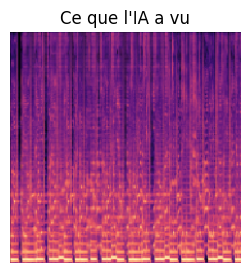

In [ ]:
predict_genre("/content/3657013892_Baddest B_tch in Town.mp3")